In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi gaya visualisasi agar seragam dan profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries berhasil dimuat. Siap melakukan EDA mendalam.")

Libraries berhasil dimuat. Siap melakukan EDA mendalam.


In [2]:
print("=== 1. DATA INTEGRITY CHECK: POWER HISTORY ===")
df_power = pd.read_csv('../data/power_history.csv')

# 1. Cek ukuran data
print(f"Dimensi Dataset: {df_power.shape[0]} baris, {df_power.shape[1]} kolom")

# 2. Cek tipe data dan kelengkapan informasi
print("\nInformasi Struktur Data:")
print(df_power.info())

# 3. Validasi Missing Values (Wajib untuk membuktikan data bersih)
missing_power = df_power.isnull().sum()
print("\nJumlah Missing Value per Kolom:")
print(missing_power)

# 4. Cek data duplikat
duplicate_power = df_power.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {duplicate_power}")

print("\nKESIMPULAN VALIDASI: Data bersih, tidak ada missing value atau duplikasi. Siap digunakan!")
df_power.head()

=== 1. DATA INTEGRITY CHECK: POWER HISTORY ===
Dimensi Dataset: 6000 baris, 6 kolom

Informasi Struktur Data:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hour          6000 non-null   int64  
 1   day_of_week   6000 non-null   int64  
 2   temperature   6000 non-null   float64
 3   prev_demand   6000 non-null   float64
 4   zone          6000 non-null   str    
 5   power_demand  6000 non-null   float64
dtypes: float64(3), int64(2), str(1)
memory usage: 310.7 KB
None

Jumlah Missing Value per Kolom:
hour            0
day_of_week     0
temperature     0
prev_demand     0
zone            0
power_demand    0
dtype: int64

Jumlah Baris Duplikat: 0

KESIMPULAN VALIDASI: Data bersih, tidak ada missing value atau duplikasi. Siap digunakan!


,hour,day_of_week,temperature,prev_demand,zone,power_demand
0,0,2,33.1,317.54,zone1,327.72
1,1,2,25.4,373.73,zone2,239.77
2,2,2,26.0,411.33,zone3,316.02
3,3,2,26.6,444.15,zone4,338.23
4,4,2,28.9,460.55,zone1,381.06


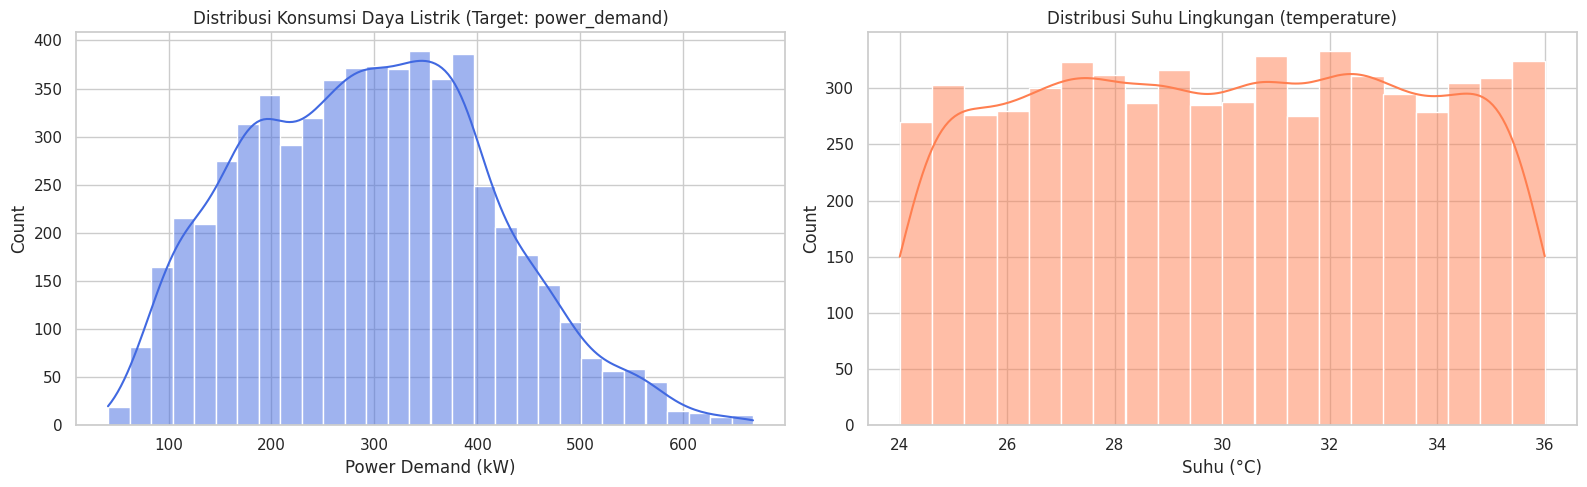

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi Target (Power Demand)
sns.histplot(df_power['power_demand'], kde=True, ax=axes[0], color='royalblue', bins=30)
axes[0].set_title('Distribusi Konsumsi Daya Listrik (Target: power_demand)')
axes[0].set_xlabel('Power Demand (kW)')

# Distribusi Suhu
sns.histplot(df_power['temperature'], kde=True, ax=axes[1], color='coral', bins=20)
axes[1].set_title('Distribusi Suhu Lingkungan (temperature)')
axes[1].set_xlabel('Suhu (°C)')

plt.tight_layout()
plt.show()

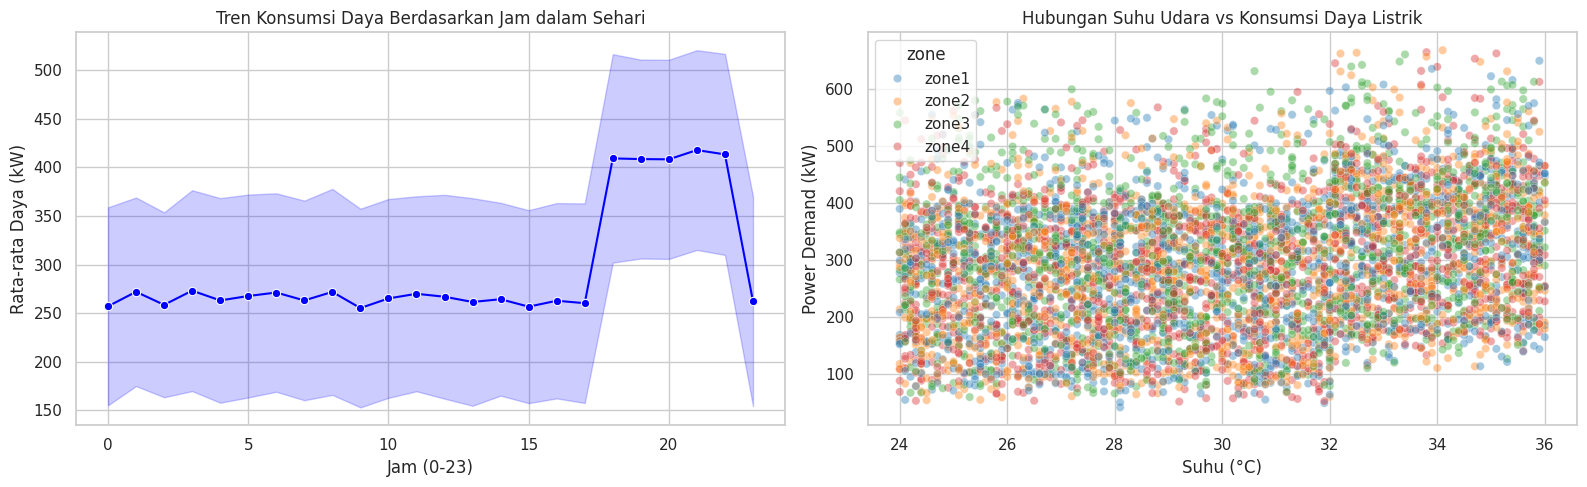

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hubungan Jam vs Power Demand (Membuktikan pola Peak Hours)
sns.lineplot(data=df_power, x='hour', y='power_demand', ax=axes[0], color='blue', marker='o', errorbar='sd')
axes[0].set_title('Tren Konsumsi Daya Berdasarkan Jam dalam Sehari')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Rata-rata Daya (kW)')

# Hubungan Suhu vs Power Demand (Membuktikan dampak cuaca terhadap beban listrik)
sns.scatterplot(data=df_power, x='temperature', y='power_demand', hue='zone', alpha=0.4, ax=axes[1], palette='tab10')
axes[1].set_title('Hubungan Suhu Udara vs Konsumsi Daya Listrik')
axes[1].set_xlabel('Suhu (°C)')
axes[1].set_ylabel('Power Demand (kW)')

plt.tight_layout()
plt.show()

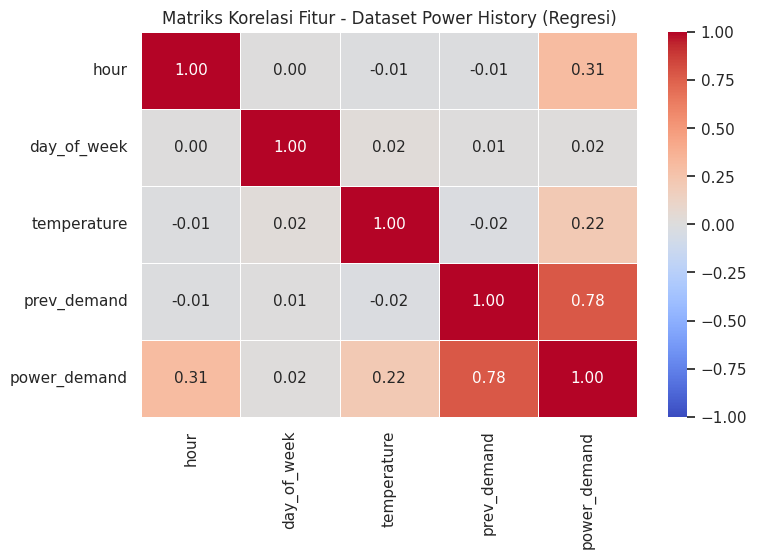

In [5]:
plt.figure(figsize=(8, 5))
# Memilih hanya kolom numerik untuk korelasi
numerical_cols_p = df_power.select_dtypes(include=[np.number]).columns
corr_matrix_p = df_power[numerical_cols_p].corr()

sns.heatmap(corr_matrix_p, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur - Dataset Power History (Regresi)')
plt.show()

In [6]:
print("=== 2. DATA INTEGRITY CHECK: GRID QUALITY ===")
df_grid = pd.read_csv('../data/grid_quality.csv')

print(f"Dimensi Dataset: {df_grid.shape[0]} baris, {df_grid.shape[1]} kolom")

# Cek Missing Value & Duplikasi
print(f"Total Missing Values: {df_grid.isnull().sum().sum()}")
print(f"Total Baris Duplikat: {df_grid.duplicated().sum()}")

# Cek Keseimbangan Kelas (Class Balance) untuk Klasifikasi
print("\nDistribusi Kelas Target (grid_status):")
print(df_grid['grid_status'].value_counts())

print("\nKESIMPULAN VALIDASI: Data siap digunakan untuk training model klasifikasi multi-kelas.")

=== 2. DATA INTEGRITY CHECK: GRID QUALITY ===
Dimensi Dataset: 6000 baris, 6 kolom
Total Missing Values: 0
Total Baris Duplikat: 0

Distribusi Kelas Target (grid_status):
grid_status
Normal      3547
Warning     1279
Critical    1174
Name: count, dtype: int64

KESIMPULAN VALIDASI: Data siap digunakan untuk training model klasifikasi multi-kelas.


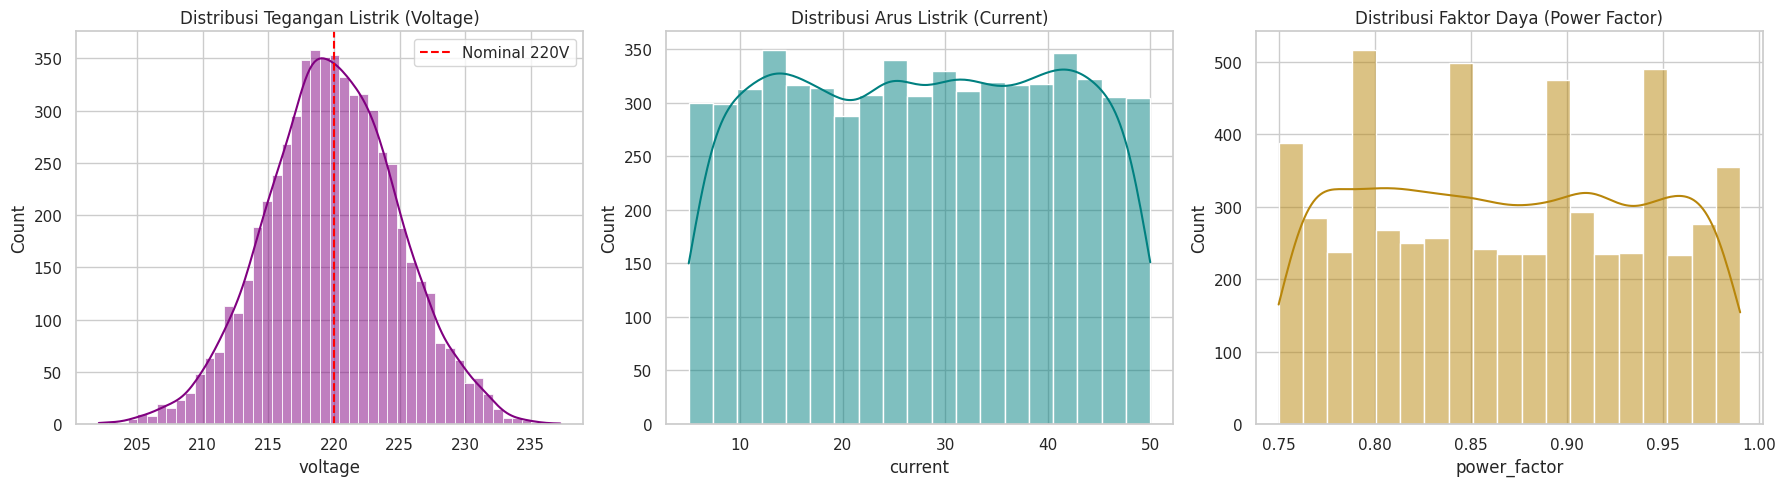

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Tegangan (Voltage)
sns.histplot(df_grid['voltage'], kde=True, ax=axes[0], color='purple')
axes[0].axvline(220, color='red', linestyle='--', label='Nominal 220V')
axes[0].set_title('Distribusi Tegangan Listrik (Voltage)')
axes[0].legend()

# Distribusi Arus (Current)
sns.histplot(df_grid['current'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribusi Arus Listrik (Current)')

# Distribusi Power Factor
sns.histplot(df_grid['power_factor'], kde=True, ax=axes[2], color='darkgoldenrod')
axes[2].set_title('Distribusi Faktor Daya (Power Factor)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_17586/1443603887.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grid, x='grid_status', y='power_factor', palette='Set2', ax=axes[1])


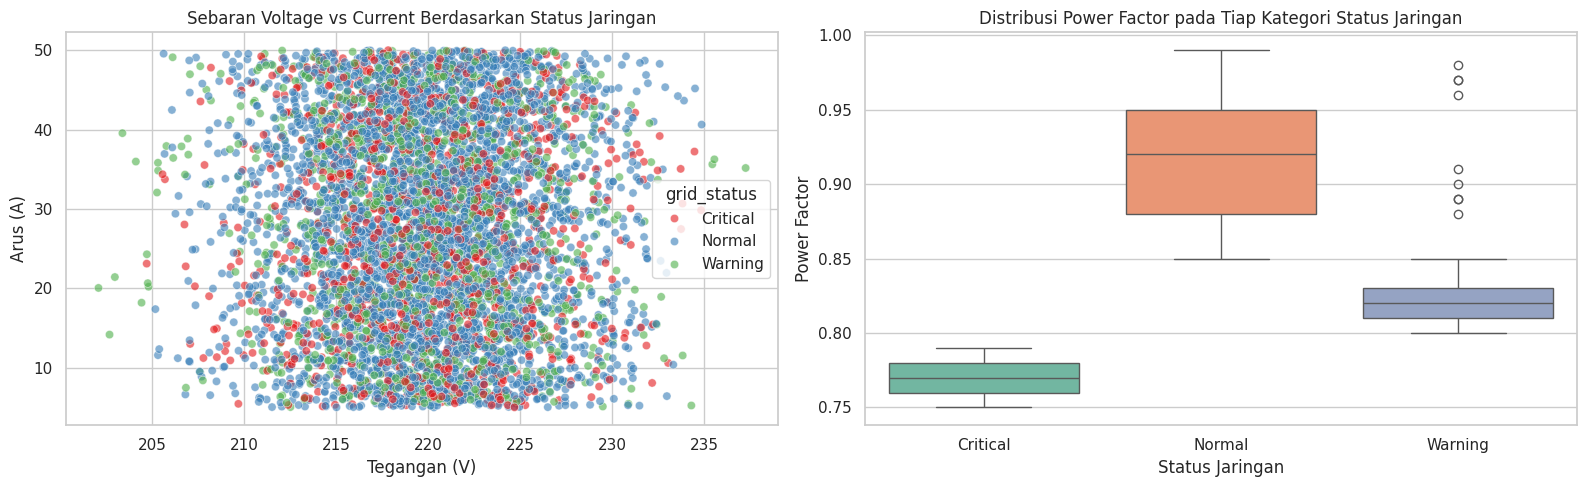

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot hubungan Voltage vs Current dipisahkan warna status jaringan
sns.scatterplot(data=df_grid, x='voltage', y='current', hue='grid_status', palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Sebaran Voltage vs Current Berdasarkan Status Jaringan')
axes[0].set_xlabel('Tegangan (V)')
axes[0].set_ylabel('Arus (A)')

# Boxplot Faktor Daya terhadap Status Jaringan
sns.boxplot(data=df_grid, x='grid_status', y='power_factor', palette='Set2', ax=axes[1])
axes[1].set_title('Distribusi Power Factor pada Tiap Kategori Status Jaringan')
axes[1].set_xlabel('Status Jaringan')
axes[1].set_ylabel('Power Factor')

plt.tight_layout()
plt.show()

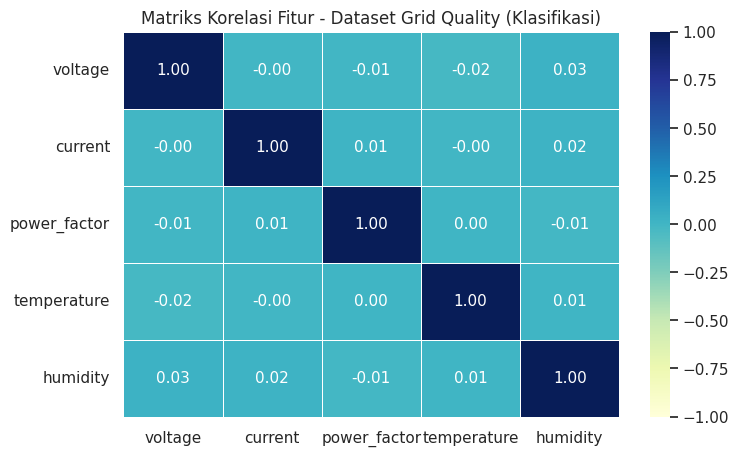

In [9]:
plt.figure(figsize=(8, 5))
numerical_cols_g = df_grid.select_dtypes(include=[np.number]).columns
corr_matrix_g = df_grid[numerical_cols_g].corr()

sns.heatmap(corr_matrix_g, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur - Dataset Grid Quality (Klasifikasi)')
plt.show()

In [10]:
print("=== 3. DATA INTEGRITY CHECK: ENERGY SENSORS ===")
df_sensors = pd.read_csv('../data/energy_sensors.csv')

print(f"Dimensi Dataset: {df_sensors.shape[0]} baris, {df_sensors.shape[1]} kolom")
print(f"Total Missing Values: {df_sensors.isnull().sum().sum()}")
print(f"Total Baris Duplikat: {df_sensors.duplicated().sum()}")

print("\nStatistik Deskriptif Fitur Utama:")
print(df_sensors.describe())

=== 3. DATA INTEGRITY CHECK: ENERGY SENSORS ===
Dimensi Dataset: 6000 baris, 4 kolom
Total Missing Values: 0
Total Baris Duplikat: 0

Statistik Deskriptif Fitur Utama:
       sensor_value  timestamp_hour  rolling_mean_1h      z_score
count   6000.000000     6000.000000      6000.000000  6000.000000
mean     116.169650       11.500000       116.248575     1.077965
std       69.875871        6.922763        70.071383     4.658409
min       40.620000        0.000000        33.480000    -3.960000
25%       90.817500        5.750000        90.157500    -0.610000
50%      101.270000       11.500000       101.390000     0.080000
75%      112.472500       17.250000       113.442500     0.830000
max      499.340000       23.000000       508.900000    26.620000


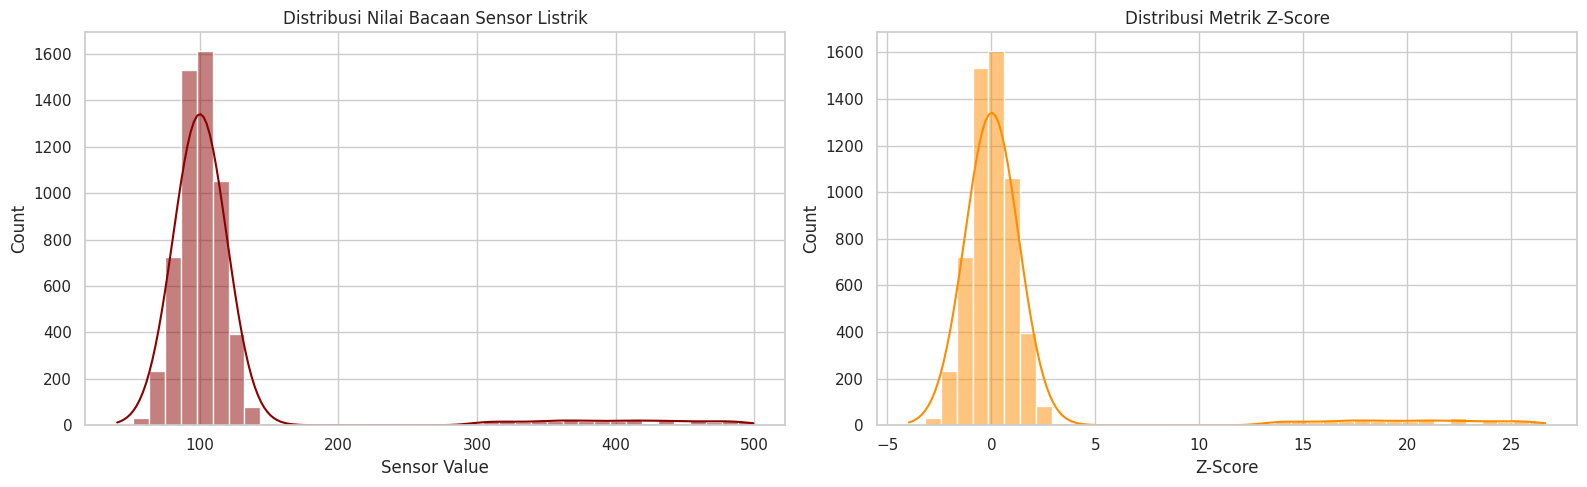

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi Nilai Sensor
sns.histplot(df_sensors['sensor_value'], kde=True, ax=axes[0], color='darkred', bins=40)
axes[0].set_title('Distribusi Nilai Bacaan Sensor Listrik')
axes[0].set_xlabel('Sensor Value')

# Distribusi Z-Score untuk analisis matematis pencilan
sns.histplot(df_sensors['z_score'], kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('Distribusi Metrik Z-Score')
axes[1].set_xlabel('Z-Score')

plt.tight_layout()
plt.show()

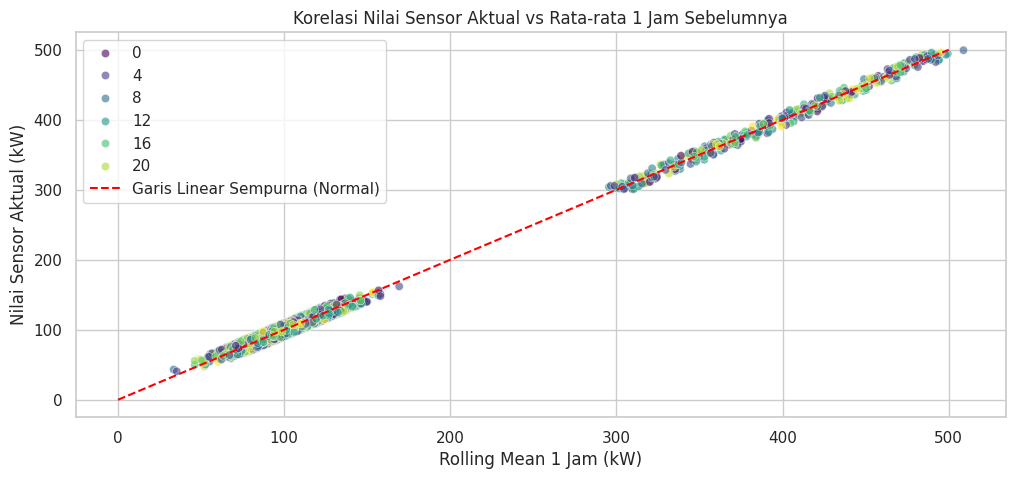

In [12]:
# Menganalisis deviasi nilai sensor saat ini terhadap rata-rata bergulir 1 jam sebelumnya
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_sensors, x='rolling_mean_1h', y='sensor_value', hue='timestamp_hour', palette='viridis', alpha=0.6)
plt.plot([0, 500], [0, 500], color='red', linestyle='--', label='Garis Linear Sempurna (Normal)')
plt.title('Korelasi Nilai Sensor Aktual vs Rata-rata 1 Jam Sebelumnya')
plt.xlabel('Rolling Mean 1 Jam (kW)')
plt.ylabel('Nilai Sensor Aktual (kW)')
plt.legend()
plt.show()

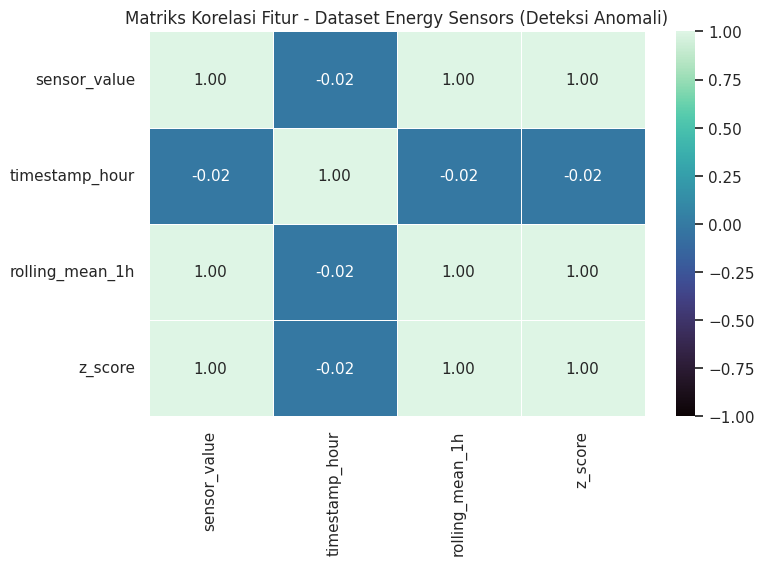

In [13]:
plt.figure(figsize=(8, 5))
corr_matrix_s = df_sensors.corr()

sns.heatmap(corr_matrix_s, annot=True, cmap='mako', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur - Dataset Energy Sensors (Deteksi Anomali)')
plt.show()